# Goal: Create a diverse playlist (100-Songs) from the top 100 songs from the past 10 years (879 songs minus the repeat and undownloadable ones) via VGGish Embeddings

This notebook:
1. Loads songs from `songs/`
2. Computes each song's **128-D VGGish embedding** (mean over patches)
3. Selects a playlist of size `K` to maximize diversity in embedding space
4. Prints the diversity report directly in the notebook output

In [ ]:
# %pip install numpy pandas librosa soundfile tensorflow tensorflow-hub scikit-learn tqdm

In [ ]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import librosa
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.metrics import pairwise_distances

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT = Path.cwd()
SONGS_DIR = ROOT / "songs"
OUT_DIR = ROOT / "selected_songs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_FILE = OUT_DIR / "vggish_song_embeddings.csv"
PLAYLIST_FILE = OUT_DIR / "diverse_playlist_100.csv"

TARGET_SR = 16000
MAX_SECONDS = 120  # crop long songs for faster processing
K = 100  # tentative playlist size

song_files = sorted(SONGS_DIR.glob("*.mp3"))
print(f"Found {len(song_files)} songs in {SONGS_DIR}")
if len(song_files) == 0:
    raise FileNotFoundError(f"No MP3 files found in {SONGS_DIR}")

c:\Users\abepa\OneDrive\Desktop\School stuff\DecodedBrain\UCSD-Brain-to-Music-Interface\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\abepa\OneDrive\Desktop\School stuff\DecodedBrain\UCSD-Brain-to-Music-Interface\.venv\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version



Found 879 songs in c:\Users\abepa\OneDrive\Desktop\School stuff\DecodedBrain\UCSD-Brain-to-Music-Interface\songs


In [2]:
# Load VGGish model from TensorFlow Hub
# Output shape: [num_patches, 128]
vggish = hub.load("https://tfhub.dev/google/vggish/1")
print("Loaded VGGish model.")

Loaded VGGish model.


In [3]:
def embed_song_vggish(path: Path, target_sr: int = 16000, max_seconds: int = 120) -> np.ndarray:
    """Return a 128-D embedding for one song via patch mean of VGGish outputs."""
    audio, sr = librosa.load(path, sr=target_sr, mono=True)
    if max_seconds is not None and max_seconds > 0:
        max_len = int(max_seconds * target_sr)
        if len(audio) > max_len:
            audio = audio[:max_len]

    # Ensure float32 in [-1, 1]
    audio = np.asarray(audio, dtype=np.float32)
    if audio.size == 0:
        raise ValueError("Empty audio signal")

    patch_embeddings = vggish(audio)  # [n_patches, 128]
    patch_embeddings = np.asarray(patch_embeddings)
    if patch_embeddings.ndim != 2 or patch_embeddings.shape[1] != 128:
        raise ValueError(f"Unexpected embedding shape: {patch_embeddings.shape}")

    song_embedding = patch_embeddings.mean(axis=0)
    return song_embedding.astype(np.float32)


def l2_normalize_rows(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norms, eps)


def load_or_build_embedding_table(song_paths, cache_file: Path) -> pd.DataFrame:
    emb_cols = [f"emb_{i}" for i in range(128)]

    if cache_file.exists():
        cached = pd.read_csv(cache_file)
        needed_cols = {"song_name", "file_path"} | set(emb_cols)
        if needed_cols.issubset(cached.columns):
            cached = cached.drop_duplicates(subset=["file_path"]).reset_index(drop=True)
            existing = set(cached["file_path"].tolist())
            to_add = [p for p in song_paths if str(p) not in existing]
            print(f"Loaded cache with {len(cached)} songs; {len(to_add)} new songs to embed.")
        else:
            print("Cache format mismatch; rebuilding cache from scratch.")
            cached = pd.DataFrame(columns=["song_name", "file_path"] + emb_cols)
            to_add = list(song_paths)
    else:
        cached = pd.DataFrame(columns=["song_name", "file_path"] + emb_cols)
        to_add = list(song_paths)

    rows = []
    failures = []
    for p in tqdm(to_add, desc="Embedding songs"):
        try:
            vec = embed_song_vggish(p, target_sr=TARGET_SR, max_seconds=MAX_SECONDS)
            rows.append({
                "song_name": p.name,
                "file_path": str(p),
                **{f"emb_{i}": float(vec[i]) for i in range(128)}
            })
        except Exception as e:
            failures.append((p.name, str(e)))

    if rows:
        new_df = pd.DataFrame(rows)
        cached = pd.concat([cached, new_df], ignore_index=True)

    # Deduplicate by full path, keep first
    cached = cached.drop_duplicates(subset=["file_path"]).reset_index(drop=True)
    cached.to_csv(cache_file, index=False)

    if failures:
        print(f"Skipped {len(failures)} files due to errors.")
        fail_df = pd.DataFrame(failures, columns=["song_name", "error"])
        fail_df.to_csv(OUT_DIR / "vggish_embedding_failures.csv", index=False)

    return cached

In [4]:
embedding_df = load_or_build_embedding_table(song_files, CACHE_FILE)
emb_cols = [f"emb_{i}" for i in range(128)]

# Keep only finite embeddings
embedding_df = embedding_df.replace([np.inf, -np.inf], np.nan).dropna(subset=emb_cols).reset_index(drop=True)

X = embedding_df[emb_cols].to_numpy(dtype=np.float32)
X = l2_normalize_rows(X)

print(f"Usable songs with valid 128-D embeddings: {len(embedding_df)}")
if len(embedding_df) < 2:
    raise ValueError("Need at least 2 valid songs to compute diversity.")

Embedding songs: 100%|██████████| 879/879 [21:55<00:00,  1.50s/it]


Usable songs with valid 128-D embeddings: 879


In [ ]:
def farthest_point_sampling(X: np.ndarray, k: int, seed: int = 42):
    """Greedy k-center approximation: iteratively add the farthest point from selected set."""
    n = X.shape[0]
    k = min(k, n)

    centroid = X.mean(axis=0, keepdims=True)
    d0 = pairwise_distances(X, centroid, metric="euclidean").ravel()
    first = int(np.argmax(d0))

    selected = [first]
    min_d = pairwise_distances(X, X[[first]], metric="euclidean").ravel()

    for _ in range(1, k):
        next_idx = int(np.argmax(min_d))
        selected.append(next_idx)
        d_new = pairwise_distances(X, X[[next_idx]], metric="euclidean").ravel()
        min_d = np.minimum(min_d, d_new)

    return np.array(selected, dtype=int)


def diversity_metrics(X_sel: np.ndarray):
    if X_sel.shape[0] < 2:
        return {"mean_pairwise": np.nan, "min_pairwise": np.nan, "mean_nn": np.nan}

    D = pairwise_distances(X_sel, metric="euclidean")
    iu = np.triu_indices_from(D, k=1)
    pairwise_vals = D[iu]

    D_no_diag = D + np.eye(D.shape[0]) * 1e9
    nn = D_no_diag.min(axis=1)

    return {
        "mean_pairwise": float(pairwise_vals.mean()),
        "min_pairwise": float(pairwise_vals.min()),
        "mean_nn": float(nn.mean()),
    }


k = min(K, len(embedding_df))
selected_idx = farthest_point_sampling(X, k=k, seed=SEED)
playlist_df = embedding_df.iloc[selected_idx].copy().reset_index(drop=True)
playlist_df.insert(0, "playlist_rank", np.arange(1, len(playlist_df) + 1))

# Evaluate diversity vs random baseline
sel_metrics = diversity_metrics(X[selected_idx])

rng = np.random.default_rng(SEED)
rand_trials = 100
rand_metrics = []
for _ in range(rand_trials):
    ridx = rng.choice(len(embedding_df), size=k, replace=False)
    rand_metrics.append(diversity_metrics(X[ridx]))

rand_df = pd.DataFrame(rand_metrics)
baseline = rand_df.mean(numeric_only=True).to_dict()

keep_cols = ["playlist_rank", "song_name", "file_path"]
playlist_df[keep_cols].to_csv(PLAYLIST_FILE, index=False)

report_lines = [
    "Diversity playlist report",
    f"Total candidate songs: {len(embedding_df)}",
    f"Requested K: {K}",
    f"Actual K used: {k}",
    "",
    "Selected playlist metrics:",
    f"- mean_pairwise: {sel_metrics['mean_pairwise']:.6f}",
    f"- min_pairwise: {sel_metrics['min_pairwise']:.6f}",
    f"- mean_nn: {sel_metrics['mean_nn']:.6f}",
    "",
    f"Random baseline metrics (mean over {rand_trials} trials):",
    f"- mean_pairwise: {baseline.get('mean_pairwise', np.nan):.6f}",
    f"- min_pairwise: {baseline.get('min_pairwise', np.nan):.6f}",
    f"- mean_nn: {baseline.get('mean_nn', np.nan):.6f}",
    "",
    "Improvement over random baseline:",
    f"- mean_pairwise delta: {(sel_metrics['mean_pairwise'] - baseline.get('mean_pairwise', np.nan)):.6f}",
    f"- min_pairwise delta: {(sel_metrics['min_pairwise'] - baseline.get('min_pairwise', np.nan)):.6f}",
    f"- mean_nn delta: {(sel_metrics['mean_nn'] - baseline.get('mean_nn', np.nan)):.6f}",
]

print("\n".join(report_lines))
print(f"Saved playlist: {PLAYLIST_FILE}")
playlist_df[keep_cols].head(15)

Saved playlist: c:\Users\abepa\OneDrive\Desktop\School stuff\DecodedBrain\UCSD-Brain-to-Music-Interface\selected_songs\diverse_playlist_100.csv
Saved report:   c:\Users\abepa\OneDrive\Desktop\School stuff\DecodedBrain\UCSD-Brain-to-Music-Interface\selected_songs\diversity_report.txt
Diversity playlist report
Total candidate songs: 879
Requested K: 100
Actual K used: 100

Selected playlist metrics:
- mean_pairwise: 0.591039
- min_pairwise: 0.326211
- mean_nn: 0.353009



,playlist_rank,song_name,file_path
0,1,justin timberlake featuring chris stapleton - ...,c:\Users\abepa\OneDrive\Desktop\School stuff\D...
1,2,daddy yankee & katy perry featuring snow - con...,c:\Users\abepa\OneDrive\Desktop\School stuff\D...
2,3,luke combs - ain't no love in oklahoma.mp3,c:\Users\abepa\OneDrive\Desktop\School stuff\D...
3,4,21 savage - bank account.mp3,c:\Users\abepa\OneDrive\Desktop\School stuff\D...
4,5,xavi - la diabla.mp3,c:\Users\abepa\OneDrive\Desktop\School stuff\D...
5,6,surf mesa featuring emilee - ily.mp3,c:\Users\abepa\OneDrive\Desktop\School stuff\D...
6,7,"tyler, the creator featuring glorilla, sexyy r...",c:\Users\abepa\OneDrive\Desktop\School stuff\D...
7,8,billie eilish - happier than ever.mp3,c:\Users\abepa\OneDrive\Desktop\School stuff\D...
8,9,justin bieber - love yourself.mp3,c:\Users\abepa\OneDrive\Desktop\School stuff\D...
9,10,taylor swift - anti-hero.mp3,c:\Users\abepa\OneDrive\Desktop\School stuff\D...


## Notes

- Re-running will reuse cached embeddings in `selected_songs/vggish_song_embeddings.csv`.
- If you change `MAX_SECONDS`, delete cache to recompute consistently.
- To try a different playlist size, change `K` and rerun the last 2 code cells.

C:\Users\abepa\AppData\Local\Temp\ipykernel_5184\688847347.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=[labels[m] for m in metrics], patch_artist=True)


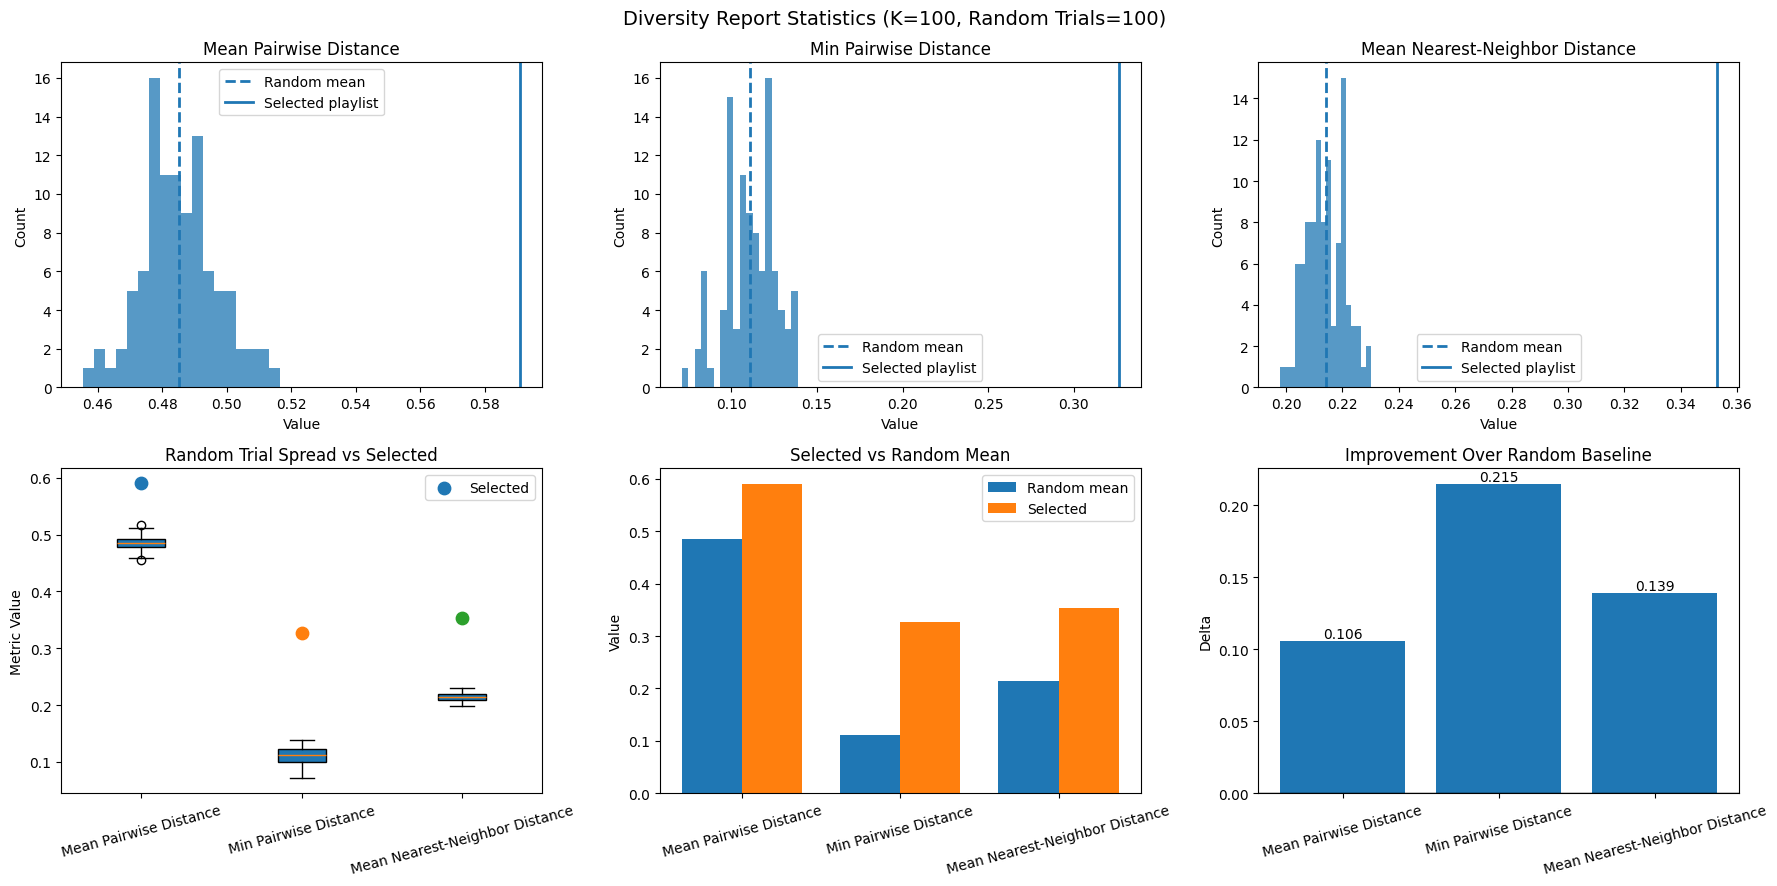

Saved statistical plots to: c:\Users\abepa\OneDrive\Desktop\School stuff\DecodedBrain\UCSD-Brain-to-Music-Interface\selected_songs\diversity_report_plots.png


,metric,selected,random_mean,delta
0,mean_pairwise,0.591039,0.485310,0.105729
1,min_pairwise,0.326211,0.111095,0.215116
2,mean_nn,0.353009,0.214102,0.138907


In [6]:
import matplotlib.pyplot as plt

metrics = ["mean_pairwise", "min_pairwise", "mean_nn"]
labels = {
  "mean_pairwise": "Mean Pairwise Distance",
  "min_pairwise": "Min Pairwise Distance",
  "mean_nn": "Mean Nearest-Neighbor Distance",
}

baseline_stats = rand_df[metrics].mean()
delta_stats = {m: sel_metrics[m] - baseline_stats[m] for m in metrics}

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(f"Diversity Report Statistics (K={k}, Random Trials={rand_trials})", fontsize=14)

# Row 1: random distributions + selected value
for i, m in enumerate(metrics):
  ax = axes[0, i]
  ax.hist(rand_df[m], bins=18, alpha=0.75)
  ax.axvline(baseline_stats[m], linestyle="--", linewidth=2, label="Random mean")
  ax.axvline(sel_metrics[m], linewidth=2, label="Selected playlist")
  ax.set_title(labels[m])
  ax.set_xlabel("Value")
  ax.set_ylabel("Count")
  ax.legend()

# Row 2, Col 1: boxplot of random trials with selected points
ax = axes[1, 0]
box_data = [rand_df[m].values for m in metrics]
ax.boxplot(box_data, labels=[labels[m] for m in metrics], patch_artist=True)
for i, m in enumerate(metrics, start=1):
  ax.scatter(i, sel_metrics[m], s=80, zorder=3, label="Selected" if i == 1 else None)
ax.set_title("Random Trial Spread vs Selected")
ax.set_ylabel("Metric Value")
ax.tick_params(axis="x", rotation=15)
ax.legend()

# Row 2, Col 2: selected vs random mean
ax = axes[1, 1]
x = np.arange(len(metrics))
w = 0.38
ax.bar(x - w / 2, [baseline_stats[m] for m in metrics], width=w, label="Random mean")
ax.bar(x + w / 2, [sel_metrics[m] for m in metrics], width=w, label="Selected")
ax.set_xticks(x)
ax.set_xticklabels([labels[m] for m in metrics], rotation=15)
ax.set_title("Selected vs Random Mean")
ax.set_ylabel("Value")
ax.legend()

# Row 2, Col 3: improvement deltas
ax = axes[1, 2]
deltas = [delta_stats[m] for m in metrics]
bars = ax.bar([labels[m] for m in metrics], deltas)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Improvement Over Random Baseline")
ax.set_ylabel("Delta")
ax.tick_params(axis="x", rotation=15)
for b, d in zip(bars, deltas):
  ax.text(b.get_x() + b.get_width() / 2, d, f"{d:.3f}", ha="center", va="bottom")

plt.tight_layout()
plot_file = OUT_DIR / "diversity_report_plots.png"
plt.savefig(plot_file, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved statistical plots to: {plot_file}")
pd.DataFrame({
  "metric": metrics,
  "selected": [sel_metrics[m] for m in metrics],
  "random_mean": [baseline_stats[m] for m in metrics],
  "delta": [delta_stats[m] for m in metrics],
})